In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
#from sklearn.cross_decomposition import CCA
from mvlearn.embed import CCA
from scipy.stats import pearsonr 
from scipy import stats
from typing import List, Tuple, Optional
import numpy as np


###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

In [2]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#", skiprows=1,
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                #eeg_norm = normalise_eeg(eeg)           # your helper from before
                #pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg), len(pupil))
                eeg = eeg[0:T, :]  # (T × n_channels)
                pupil  = pupil[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg, pupil, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials
    
def split_trials_by_load(trials: List[Tuple[np.ndarray, np.ndarray, dict]]
                         ) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into 05, 09 and 13 load sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'load'.

    Returns
    -------
    load_05_trials  : list[tuple]
    load_09_trials  : list[tuple]
    load_13_trials  : list[tuple]
    """
    load_05_trials = []
    load_09_trials = []
    load_13_trials = []

    for eeg, pupil, meta in trials:
        load = meta.get("load")
        if load == 5:
            load_05_trials.append((eeg, pupil, meta))
        elif load == 9:
            load_09_trials.append((eeg, pupil, meta))
        elif load == 13:
            load_13_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown load label: {load}")

    return load_05_trials, load_09_trials, load_13_trials

In [3]:
from typing import List, Tuple, Optional, Dict
def concat_trials(
    trials: List[Tuple[np.ndarray, np.ndarray, dict]],
    shift: int = 0,  # samples; positive = EEG delayed (EEG after pupil)
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate trials for CCA without circular wrap.

    Returns
    -------
    X : ndarray, shape (Σ T_eff, n_channels)   # EEG
    Y : ndarray, shape (Σ T_eff, 1)            # pupil
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # Ensure 1D/2D shapes: EEG (T, C), pupil (T, 1)
        if eeg.ndim == 1:
            eeg = eeg[:, None]
        if pupil_z.ndim == 1:
            pupil_z = pupil_z[:, None]

        T = min(len(eeg), len(pupil_z))
        if T == 0:
            print("Warning: zero-length trial encountered - skipped")
            continue

        # Optional common window first (keeps boundaries away)
        start = WIN_OFFSET1
        stop  = T - WIN_OFFSET2
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]
        Tw = len(eeg_w)

        # Apply lag by asymmetric trimming (no roll, no wrap)
        # Positive shift => EEG delayed => drop 'shift' from EEG start and pupil end
        # Negative shift => EEG advanced => drop '-shift' from pupil start and EEG end
        if shift >= 0:
            if Tw <= shift:
                continue  # nothing left after lag
            eeg_seg   = eeg_w[shift:]             # drop early EEG
            pupil_seg = pupil_w[:Tw - shift]      # drop late pupil
        else:
            s = -shift
            if Tw <= s:
                continue
            eeg_seg   = eeg_w[:Tw - s]            # drop late EEG
            pupil_seg = pupil_w[s:]               # drop early pupil
    
        eeg_seg = normalise_eeg(eeg_seg)           # your helper from before
        pupil_seg = ((pupil_seg - pupil_seg.mean()) / pupil_seg.std(ddof=0))

        # Shapes now match
        X_blocks.append(eeg_seg)
        Y_blocks.append(pupil_seg)

    if not X_blocks:
        print("Warning: no valid trials after concatenation - returning empty arrays")
        return np.empty((0, trials[0][0].shape[-1])), np.empty((0, 1))

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift):
    """
    Yield (eeg_aligned, pupil_aligned, meta) one by one, with no circular wrap.

    Conventions
    -----------
    - `shift` in samples, along time axis (axis=0).
    - shift >= 0  → EEG delayed  → drop early EEG, drop late pupil
    - shift <  0  → EEG advanced → drop late EEG, drop early pupil
    """
    for eeg, pupil_z, meta in trials:
        # Window first
        T = min(len(eeg), len(pupil_z))
        start = WIN_OFFSET1
        stop  = T - 50
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]

        # Ensure both have time along axis 0 and share the same window length
        Tw = len(eeg_w)
        
        if Tw == 0: continue

        if shift >= 0: # EEG delayed: drop early EEG, drop late pupil
            eeg_out   = eeg_w[shift:]           # works for 1D or 2D (time on axis 0)
            pupil_out = pupil_w[:Tw - shift]
        else:
            s = -shift # EEG advanced: drop late EEG, drop early pupil
            
            eeg_out   = eeg_w[:Tw - s]
            pupil_out = pupil_w[s:]

        eeg_out = normalise_eeg(eeg_out)
        pupil_out = ((pupil_out - pupil_out.mean()) / pupil_out.std(ddof=0))

        yield eeg_out, pupil_out, meta.copy()

In [4]:
# ---------- HELPERS --------------------------------------------
import matplotlib.pyplot as plt
def find_weight_file(subj: int,
                     base_dir: Path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\cca_weights_slow")
                     ) -> Path:
    """
    Find the CSV for given condition ('ctrl' or 'mem') for the chosen subject.
    If lag_ms is provided, match exactly. Otherwise, take any that matches.
    """
    subj_str = f"{subj:03d}"
    subj_glob = f"sub-{subj_str}_eeg_weights_mem_*.csv"
    candidates = list((base_dir).glob(subj_glob))
    if not candidates:
        return None
    if len(candidates) > 1:
        return None  # ambiguous
    return candidates[0]

def load_weights(subj: int):
    csv_path = find_weight_file(subj)
    if csv_path is None or not csv_path.exists():
        return None, None
    df = pd.read_csv(csv_path)
    ch_names = df['channel'].tolist()
    weights  = df['weight'].to_numpy()
    return ch_names, weights

Subject 033
0 AFz 0.278900486484387
1 AF3 0.0485438566857844
2 AF4 -0.2468438145717439
3 Fz 0.1065301683784249
4 F1 0.4387985031615437
5 F2 -0.3436517481774732
6 F3 -0.1154217327266433
7 F4 0.2625875783852091
8 FC3 0.3651656561204436
9 FC1 -0.2926079826386568
10 FC2 0.1561811958407624
11 FC4 0.0203020058904463
12 Cz 0.0045998641338981
13 C3 -0.3164834725369064
14 C1 -0.0089152278614427
15 C2 0.3237225512869098
16 C4 -0.0763777455149311
Subject 034
0 AFz 0.1655912089700122
1 AF3 0.0489771978504247
2 AF4 0.2577305648047665
3 Fz -0.0114775769515963
4 F1 -0.107523696679847
5 F2 -0.0500670600128871
6 F3 0.2192285364958028
7 F4 -0.1125631295258037
8 FC3 0.1034477835388005
9 FC1 0.4275235275153671
10 FC2 0.050326857352195
11 FC4 -0.0263598253152453
12 Cz -0.462024867017909
13 C3 -0.5633393656889819
14 C1 0.14921457467183
15 C2 -0.1158477708120469
16 C4 -0.2561542195090102
Subject 035
0 AFz 0.3588754073580433
1 AF3 -0.3959634242864229
2 AF4 0.003984306912264
3 Fz -0.3658414167292786
4 F1 0.414

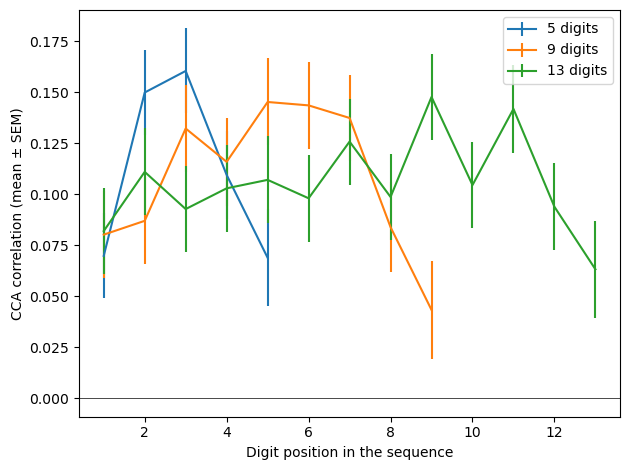

In [5]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    print(f"Subject {subj:03d}")
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)

    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_memory, best_shift):
        n_digits = meta['load']
        
        channel_out = 5  # F1 channel index
        eeg_s_no_ch = np.delete(eeg_s, channel_out, axis=1)
        weights_no_ch = np.delete(weights, channel_out)
        

        cv_eeg = np.dot(eeg_s, weights)
        cv_pupil = pupil_s.ravel()
        cv_eeg_no_ch = np.dot(eeg_s_no_ch, weights_no_ch)

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            x_no_ch = cv_eeg_no_ch[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]


            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'eeg_channels': np.mean(eeg_s[w, :], axis=0),
                'F1': float(np.mean(eeg_s[w, channel_out])),  # mean EEG, F1 signal in this digit
                'eeg_cca': float(np.mean(x)),  # mean CCA component in this digit
                'eeg_cca_no_ch': float(np.mean(x_no_ch)),  # mean CCA without F1
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'memory'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("mem_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("mem_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

In [1]:
%matplotlib qt
# %matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

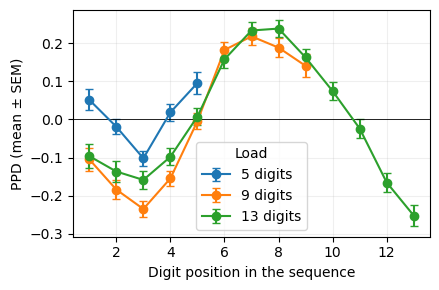

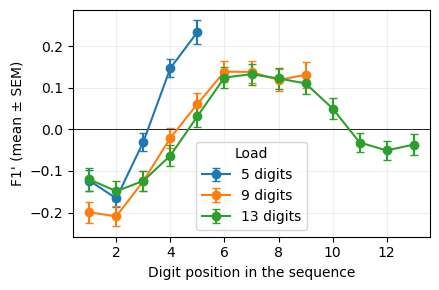

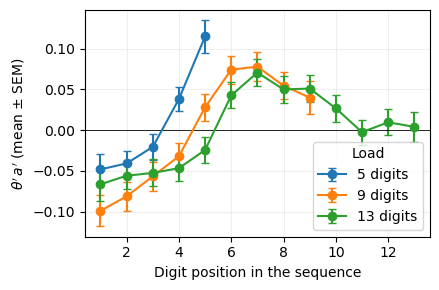

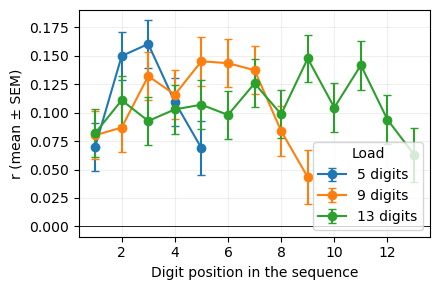

In [ ]:
import pandas as pd
def parse_vec(s: str) -> np.ndarray:
    return np.fromstring(s.strip('[]'), sep=' ')

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
idx = 4  # the channel you want

mem['eeg_channels'] = mem['eeg_channels'].apply(parse_vec)
mem['eeg_sel'] = mem['eeg_channels'].apply(lambda a: a[idx])

# Aggregate (mean ± SEM) per load × digit_pos, memory only
agg = {"mean": "mean", "sem": "sem"}
grand = {
    "pupil": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['pupil'].agg(['mean','sem']).reset_index()),
    "F1'": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['eeg_sel'].agg(['mean','sem']).reset_index()),
    "eeg_cca_no_ch": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['eeg_cca_no_ch'].agg(['mean','sem']).reset_index()),
    "r": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['r'].agg(['mean','sem']).reset_index()),
}

ylabels = {
    "F1'": "F1' (mean ± SEM)",
    "pupil": "PPD (mean ± SEM)",
    "eeg_cca_no_ch": r"$\theta' \, a'$ (mean ± SEM)",
    "r": "r (mean ± SEM)",
}

loads = [5, 9, 13]

for name, df in grand.items():
    plt.figure(figsize=(4.5,3))
    for L in loads:
        sub = df[df["load"] == L].copy()
        # ensure numeric and sorted x
        sub["digit_pos"] = pd.to_numeric(sub["digit_pos"], errors="coerce")
        sub = sub.dropna(subset=["digit_pos"]).sort_values("digit_pos")
        plt.errorbar(sub["digit_pos"], sub["mean"], yerr=sub["sem"], marker="o", linestyle="-", capsize=3, label=f"{L} digits")
    plt.axhline(0, lw=.6, color="k")
    plt.xlabel("Digit position in the sequence")
    plt.ylabel(ylabels.get(name, f"{name} (mean ± SEM)"))
    #plt.title(f"Grand {name} vs. digit position (memory)")
    plt.legend(title="Load")
    plt.grid(alpha=.2)
    plt.tight_layout()
    # plt.show()  # optional in notebooks


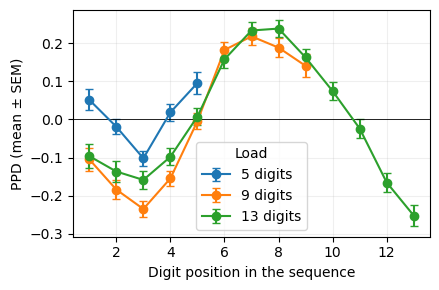

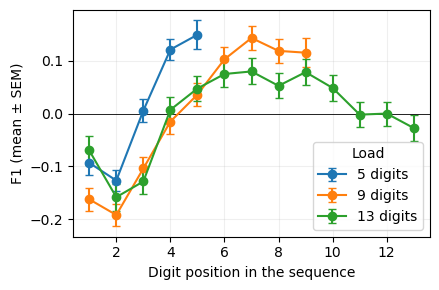

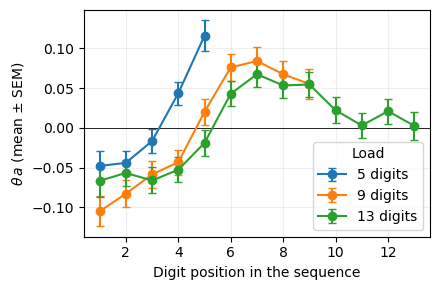

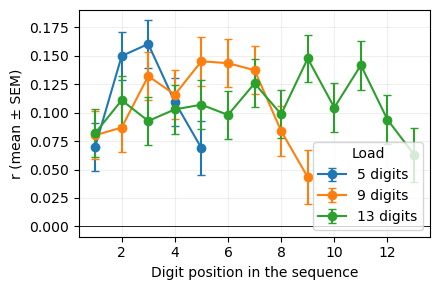

In [7]:
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")

# Aggregate (mean ± SEM) per load × digit_pos, memory only
agg = {"mean": "mean", "sem": "sem"}
grand = {
    "pupil": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['pupil'].agg(['mean','sem']).reset_index()),
    "F1": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['F1'].agg(['mean','sem']).reset_index()),
    "eeg_cca": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['eeg_cca'].agg(['mean','sem']).reset_index()),
    "r": (mem.query("condition == 'memory'")
              .groupby(['load','digit_pos'])['r'].agg(['mean','sem']).reset_index()),
}

ylabels = {
    "F1": "F1 (mean ± SEM)",
    "pupil": "PPD (mean ± SEM)",
    "eeg_cca": r"$\theta \, a$ (mean ± SEM)",
    "r": "r (mean ± SEM)",
}

loads = [5, 9, 13]

for name, df in grand.items():
    plt.figure(figsize=(4.5,3))
    for L in loads:
        sub = df[df["load"] == L].copy()
        # ensure numeric and sorted x
        sub["digit_pos"] = pd.to_numeric(sub["digit_pos"], errors="coerce")
        sub = sub.dropna(subset=["digit_pos"]).sort_values("digit_pos")
        plt.errorbar(sub["digit_pos"], sub["mean"], yerr=sub["sem"], marker="o", linestyle="-", capsize=3, label=f"{L} digits")
    plt.axhline(0, lw=.6, color="k")
    plt.xlabel("Digit position in the sequence")
    plt.ylabel(ylabels.get(name, f"{name} (mean ± SEM)"))
    #plt.title(f"Grand {name} vs. digit position (memory)")
    plt.legend(title="Load")
    plt.grid(alpha=.2)
    plt.tight_layout()
    # plt.show()  # optional in notebooks


In [ ]:
DIG_LEN = 200
data = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\subject_level_cca_slow.csv")
best_shift_by_sub = data.groupby("subject")["lag_ms"].agg(lambda x: x.value_counts().index[0]).to_dict()
rows_trials = []
all_rows = []
win = slice(WIN_OFFSET1, -WIN_OFFSET2)

for subj in SUBJECTS:
    best_shift = best_shift_by_sub.get(subj, 0) // 10  # convert ms to samples
    trials_memory, trials_control = split_trials_by_condition(load_all_trials(subj))
    channels_w,  weights  = load_weights(subj)
    
    if channels_w is None or weights is None:
        print(f"Missing or ambiguous weights for subject {subj:03d}, skipping subject.")
        continue
    
    for eeg_s, pupil_s, meta in iterate_trials(trials_control, best_shift, win):
        n_digits = meta['load']
        for d in range(n_digits):
            w = slice(d*DIG_LEN, (d+1)*DIG_LEN)
            cv_eeg = np.dot(eeg_s, weights)
            cv_pupil = pupil_s.ravel()

        for d in range(n_digits):
            w = slice(d * DIG_LEN, (d + 1) * DIG_LEN)
            x, y = cv_eeg[w], cv_pupil[w]
            
            if x.size == 0 or y.size == 0:
                print("Empty slice:", meta['subject'], meta['epoch'], d)
                continue

            if not np.isfinite(x).all() or not np.isfinite(y).all():
                print("Non-finite values:", meta['subject'], meta['epoch'], d, "→", np.sum(~np.isfinite(x)), "bad in X;", np.sum(~np.isfinite(y)), "bad in Y")
                continue

            if np.std(x) == 0 or np.std(y) == 0:
                print("Const window:", meta['subject'], meta['epoch'], d, np.std(x), np.std(y))
                continue

            r = pearsonr(x, y)[0]
            #r = np.corrcoef(x, y)[0, 1]

            rows_trials.append({
                'subject': meta['subject'],
                'condition': meta['condition'],
                'load': meta['load'],
                'epoch': meta['epoch'],
                'lag_ms': best_shift * 10,  # convert samples to ms
                'digit_pos': d + 1,  # 1-based digit index
                'pupil': float(np.mean(y)),  # mean pupil size in this digit
                'F1': float(np.mean(eeg_s[w, 5])),  # mean EEG, F1 signal in this digit
                'eeg_component': float(np.mean(x)),  # mean CCA component in this digit
                'r': float(r),  # convert to plain float for JSON-ability
            })

        meta['r'] = float(np.corrcoef(cv_eeg, cv_pupil)[0,1])
        meta['lag_ms'] = best_shift *10
        all_rows.append(meta)

df_sameW = pd.DataFrame(rows_trials)
grand = (df_sameW.query("condition == 'control'")
           .groupby(['load','digit_pos'])['r']
           .agg(['mean','sem'])
           .reset_index())

for L in [5,9,13]:
    sub = grand[grand.load == L]
    plt.errorbar(sub.digit_pos, sub['mean'],
                 yerr=sub['sem'], label=f"{L} digits")
plt.axhline(0, c='k', lw=.5)
plt.xlabel("Digit position in the sequence")
plt.ylabel("CCA correlation (mean ± SEM)")
plt.legend(); plt.tight_layout()

pd.DataFrame(all_rows).to_csv("ctrl_trial_level_cca_slow.csv", index=False)
print("Finished - saved per-trial correlations with plain CCA.")

pd.DataFrame(rows_trials).to_csv("ctrl_digit_level_cca_slow.csv", index=False)
print("Finished - saved per-trial and digit correlations with plain CCA.")

## Comparing mem vs ctrl digits
However since we trained on memory it is biased that memory is significant

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

# --------------------------
# Paths (edit if needed)
# --------------------------
mem_path  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
ctrl_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\ctrl_digit_level_cca_slow.csv")

# --------------------------
# Load and keep needed cols
# --------------------------
cols = ["subject","condition","load","epoch","digit_pos","pupil","eeg","eeg_component","r"]
mem  = pd.read_csv(mem_path)
ctrl = pd.read_csv(ctrl_path)
mem  = mem[[c for c in cols if c in mem.columns]].copy()
ctrl = ctrl[[c for c in cols if c in ctrl.columns]].copy()

digit = 11

# Normalize keys/types
for df in (mem, ctrl):
    df["subject"]   = df["subject"].astype(str).str.strip()
    df["digit_pos"] = pd.to_numeric(df["digit_pos"], errors="coerce")
    for v in ["pupil","eeg","eeg_component","r"]:
        if v in df.columns:
            df[v] = pd.to_numeric(df[v], errors="coerce")

mem["condition"]  = "memory"
ctrl["condition"] = "control"

# --------------------------
# Filter to digit 9 only
# --------------------------
mem9  = mem.query(f"digit_pos == {digit}").copy()
ctrl9 = ctrl.query(f"digit_pos == {digit}").copy()

# --------------------------
# Mean per subject × condition
# (averaged across epochs (and loads if multiple),
#  since you asked for “take the mean for digit 5”)
# --------------------------
vars_ = ["pupil","eeg","eeg_component","r"]
mem_mean  = mem9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)
ctrl_mean = ctrl9.groupby(["subject","condition"], as_index=False)[vars_].mean(numeric_only=True)

# Merge by subject; keep subjects that have BOTH conditions
m = (mem_mean.drop(columns="condition")
         .merge(ctrl_mean.drop(columns="condition"),
                on="subject", suffixes=("_mem","_ctrl")))

if m.empty:
    raise RuntimeError("No subjects have both memory and control data at digit_pos.")

# --------------------------
# Per-subject diffs
# --------------------------
per_subj = pd.DataFrame({"subject": m["subject"]})
for v in vars_:
    mem_v  = m[f"{v}_mem"].astype(float)
    ctrl_v = m[f"{v}_ctrl"].astype(float)
    diff   = mem_v - ctrl_v
    # relative difference vs control (percentage change if you *100)
    # handle |ctrl|=0 -> NaN
    rel    = diff / np.where(np.abs(ctrl_v) > 0, np.abs(ctrl_v), np.nan)

    per_subj[f"{v}_mean_mem"]  = mem_v
    per_subj[f"{v}_mean_ctrl"] = ctrl_v
    per_subj[f"{v}_diff"]      = diff
    per_subj[f"{v}_rel_diff"]  = rel

# Save per-subject table
out_path = Path(f"digit{digit}_per_subject_means_and_diffs.csv")
per_subj.to_csv(out_path, index=False)
print(f"Saved per-subject table: {out_path.resolve()}")

# --------------------------
# Group t-tests across subjects
# One-sample t-test on differences vs 0, one-sided (mean>0)
# --------------------------
def onesided_ttest_greater(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return {"n": len(x), "t": np.nan, "p_one_sided": np.nan}
    t, p_two = stats.ttest_1samp(x, popmean=0.0, nan_policy="omit")
    # one-sided for mean>0
    p_one = p_two/2 if t > 0 else 1 - p_two/2
    return {"n": len(x), "t": float(t), "p_one_sided": float(p_one)}

rows = []
for v in vars_:
    res_rel = onesided_ttest_greater(per_subj[f"{v}_rel_diff"])
    res_abs = onesided_ttest_greater(per_subj[f"{v}_diff"])
    rows.append({
        "variable": v,
        "RELDIFF_n": res_rel["n"],
        "RELDIFF_t": res_rel["t"],
        "RELDIFF_p_one_sided": res_rel["p_one_sided"],
        "RELDIFF_sig_0p05": (res_rel["p_one_sided"] < 0.05) if np.isfinite(res_rel["p_one_sided"]) else False,
        "ABSDIFF_n": res_abs["n"],
        "ABSDIFF_t": res_abs["t"],
        "ABSDIFF_p_one_sided": res_abs["p_one_sided"],
        "ABSDIFF_sig_0p05": (res_abs["p_one_sided"] < 0.05) if np.isfinite(res_abs["p_one_sided"]) else False,
        "mean_rel_diff": np.nanmean(per_subj[f"{v}_rel_diff"].to_numpy(dtype=float)),
        "mean_abs_diff": np.nanmean(per_subj[f"{v}_diff"].to_numpy(dtype=float)),
    })

summary = pd.DataFrame(rows)
sum_path = Path(f"digit{digit}_group_ttests_summary.csv")
summary.to_csv(sum_path, index=False)
print(f"Saved group summary: {sum_path.resolve()}")

print(f"\n=== Group t-tests (digit {digit}) ===")
print(summary.to_string(index=False))


## ANOVA for difference across digits within subjects (memory condition)

In [5]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 10.207631 1.391768e-18 4.757021e-06       False  2.532402e-08       888.666004              77 2.447942e-137 0.240870     NaN
           F1          56        13  8.988224 4.157268e-16 6.554255e-09       False  1.379066e-01       100.654889              77  3.855103e-02 0.486238     NaN
eeg_component          56        13  5.549712 4.309525e-09 3.444681e-04       False  6.198727e-03       258.265536              77  3.288765e-21 0.321871     NaN
            r          56        13  1.982784 2.339750e-02 7.535532e-02       False  1.482751e-03       330.940074              77  6.945423e-33 0.450926     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc       p-corr p-adjust     cohen
        pupil  1  2  1.430735 55.0 1.581635e-01 2.022419e-01   fdr_bh  0.132306
    

In [6]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\pairwise_memory_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant_two.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
     variable  A  B         T  dof     cohen        p-unc       p-corr
           F1  1  4 -4.537606 55.0 -0.996258 3.133053e-05 2.036484e-04
           F1  1  5 -5.066241 55.0 -1.131908 4.889369e-06 6.356180e-05
           F1  1  6 -4.796147 55.0 -1.057907 1.274065e-05 1.242214e-04
           F1  1  7 -4.594709 55.0 -1.057261 2.572385e-05 1.824055e-04
           F1  1  8 -3.696145 55.0 -0.804134 5.059324e-04 1.973136e-03
           F1  1  9 -5.003799 55.0 -1.079679 6.110118e-06 6.808417e-05
           F1  1 10 -2.803986 55.0 -0.547539 6.960955e-03 1.920791e-02
           F1  1 11 -2.475713 55.0 -0.466060 1.640492e-02 3.763481e-02
           F1  1 12 -3.175923 55.0 -0.640673 2.448770e-03 7.640162e-03
           F1  1 13 -2.567757 55.0 -0.477222 1.298357e-02 3.068844e-02
           F1  2  3 -4.625585 55.0 -0.613565 2.311369e-05 1.802868e-04
           F1  2  4 -6.260951 55.0 -1.368513 6.076922e-08 1.402938e-06
           F1  2  5 -6.694363 55.0 -1.5212

In [7]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem5 = mem[mem["load"] == 5]
mem5["subject"] = mem5["subject"].astype(str).str.strip()
mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem5[v] = pd.to_numeric(mem5[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means5 = (mem5.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means') ---
results = []
pairs = []
for v in vars_:
    long = means5[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory5_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory5_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\2588092968.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["subject"] = mem5["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\2588092968.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem5["digit_pos"] = pd.to_numeric(mem5["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\2588092968.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          57         5  3.530720 8.115121e-03 4.412767e-02       False      0.034862       182.641814               9  1.733023e-34 0.392544     NaN
           F1          57         5 16.862722 4.231900e-12 1.929132e-07       False      0.070195       144.556424               9  1.342949e-26 0.531241     NaN
eeg_component          57         5  7.548369 1.011133e-05 7.520377e-04       False      0.070380       144.413749               9  1.437006e-26 0.512445     NaN
            r          57         5  4.491501 1.646344e-03 3.037502e-03       False      0.720221        17.859430               9  3.692004e-02 0.851682     NaN

Pairwise post-hoc tests:
     variable A B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil 1 2  1.662194 56.0 1.020623e-01 0.145803   fdr_bh  0.220565
        pupil 1 

In [8]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem9 = mem[mem["load"] == 9]
mem9["subject"] = mem9["subject"].astype(str).str.strip()
mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem9[v] = pd.to_numeric(mem9[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means9 = (mem9.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means9') ---
results = []
pairs = []
for v in vars_:
    long = means9[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory9_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory9_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\1316545184.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["subject"] = mem9["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\1316545184.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem9["digit_pos"] = pd.to_numeric(mem9["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\1316545184.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

     variable  n_subjects  n_digits         F        p-unc    p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          55         9 11.342715 1.256343e-14 4.031732e-05       False      0.000036       523.031579              35  9.382892e-88 0.244015     NaN
           F1          55         9 13.439674 2.047747e-17 4.360458e-10       False      0.003128       294.856615              35  1.373809e-42 0.518838     NaN
eeg_component          55         9  7.621471 1.486732e-09 3.648209e-04       False      0.196542        83.174193              35  8.990053e-06 0.293559     NaN
            r          55         9  2.899054 3.704438e-03 1.023896e-02       False      0.236699        73.669316              35  1.499428e-04 0.717972     NaN

Pairwise post-hoc tests:
     variable A B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil 1 2  1.110379 54.0 2.717557e-01 0.315587   fdr_bh  0.113534
        pupil 1 

In [9]:
import pandas as pd
import numpy as np
import pingouin as pg

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem13 = mem[mem["load"] == 13]
mem13["subject"] = mem13["subject"].astype(str).str.strip()
mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem13[v] = pd.to_numeric(mem13[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means13 = (mem13.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

# --- RM-ANOVA and pairwise (same as before, but on 'means13') ---
results = []
pairs = []
for v in vars_:
    long = means13[["subject","digit_pos", v]].dropna()
    wide = long.pivot(index="subject", columns="digit_pos", values=v)
    keep = wide.dropna(axis=0, how="any")
    if keep.shape[0] < 2 or keep.shape[1] < 2:
        continue
    long_bal = keep.reset_index().melt(id_vars="subject", var_name="digit_pos", value_name=v)
    long_bal["digit_pos"] = long_bal["digit_pos"].astype(int)

    # RM-ANOVA
    aov = pg.rm_anova(data=long_bal, dv=v, within="digit_pos", subject="subject", detailed=True)

    # Sphericity & epsilon (your version)
    spher, W, chi2, dof, p_spher = pg.sphericity(keep, method="mauchly")
    eps_res = pg.epsilon(keep)
    try:
        eps_GG = float(eps_res.get("gg", np.nan))
        eps_HF = float(eps_res.get("hf", np.nan))
    except AttributeError:
        eps_GG = float(eps_res); eps_HF = np.nan

    results.append({
        "variable": v,
        "n_subjects": keep.shape[0],
        "n_digits": keep.shape[1],
        "F": aov.loc[0,"F"],
        "p-unc": aov.loc[0,"p-unc"],
        "p-GG-corr": aov.loc[0].get("p-GG-corr", np.nan),
        "sphericity": bool(spher),
        "W_sphericity": float(W),
        "chi2_sphericity": float(chi2),
        "dof_sphericity": int(dof),
        "p_sphericity": float(p_spher),
        "eps_GG": eps_GG,
        "eps_HF": eps_HF
    })

    # Pairwise within-subjects with FDR, Cohen's d (paired)
    ph = pg.pairwise_tests(data=long_bal, dv=v, within="digit_pos", subject="subject",
                           padjust="fdr_bh", effsize="cohen", return_desc=False)
    ph = ph[["A","B","T","dof","p-unc","p-corr","p-adjust","cohen"]].copy()
    ph.insert(0, "variable", v)
    pairs.append(ph)

pd.DataFrame(results).to_csv("rm_anova_memory13_only.csv", index=False)
pd.concat(pairs, ignore_index=True).to_csv("pairwise_memory13_only.csv", index=False)

print(pd.DataFrame(results).to_string(index=False))
print("\nPairwise post-hoc tests:")
print(pd.concat(pairs, ignore_index=True).to_string(index=False))

C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\2547525913.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["subject"] = mem13["subject"].astype(str).str.strip()
C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\2547525913.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mem13["digit_pos"] = pd.to_numeric(mem13["digit_pos"], errors="coerce")
C:\Users\cdd\AppData\Local\Temp\ipykernel_24216\2547525913.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


     variable  n_subjects  n_digits        F        p-unc  p-GG-corr  sphericity  W_sphericity  chi2_sphericity  dof_sphericity  p_sphericity   eps_GG  eps_HF
        pupil          56        13 7.788506 1.169307e-13   0.000192       False  2.660261e-08       886.163538              77 7.659494e-137 0.212338     NaN
           F1          56        13 3.968101 6.101967e-06   0.001648       False  1.529824e-02       212.368114              77  1.869941e-14 0.420890     NaN
eeg_component          56        13 4.489574 5.765545e-07   0.001424       False  6.470255e-03       256.087421              77  7.086814e-21 0.345791     NaN
            r          56        13 1.850756 3.742671e-02   0.104583       False  3.641399e-03       285.292874              77  1.956904e-25 0.409332     NaN

Pairwise post-hoc tests:
     variable  A  B         T  dof        p-unc   p-corr p-adjust     cohen
        pupil  1  2 -0.436165 55.0 6.644243e-01 0.740359   fdr_bh -0.030711
        pupil  1  3  0.1341

In [10]:
import pandas as pd
from pathlib import Path

# --- Path to your file ---
in_path = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\pairwise_memory5_only.csv")

# --- Read ---
df = pd.read_csv(in_path)

# Safety: normalize column name just in case of stray spaces/casing
df.columns = [c.strip() for c in df.columns]

# --- Filter p-corr < 0.05 ---
sig = df[df['p-corr'] < 0.05].copy().sort_values(['variable','A','B'])

print("Significant pairs (p-corr < 0.05):")
if sig.empty:
    print("None.")
else:
    # Show a compact view
    print(sig[['variable','A','B','T','dof','cohen','p-unc','p-corr']].to_string(index=False))

# --- Save filtered CSV ---
out_csv = in_path.with_name(in_path.stem + "_significant2.csv")
sig.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


Significant pairs (p-corr < 0.05):
     variable  A  B         T  dof     cohen        p-unc   p-corr
           F1  1  3 -2.338441 56.0 -0.554701 2.296030e-02 0.028700
           F1  1  4 -4.220442 56.0 -1.024858 9.020906e-05 0.000180
           F1  1  5 -4.450972 56.0 -1.018206 4.120413e-05 0.000137
           F1  2  3 -4.226884 56.0 -0.828280 8.827617e-05 0.000180
           F1  2  4 -5.925172 56.0 -1.489653 2.011268e-07 0.000001
           F1  2  5 -5.850829 56.0 -1.368426 2.654612e-07 0.000001
           F1  3  4 -3.629364 56.0 -0.566499 6.161203e-04 0.001027
           F1  3  5 -2.850432 56.0 -0.596240 6.100675e-03 0.008715
eeg_component  1  5 -3.079174 56.0 -0.733464 3.213156e-03 0.008033
eeg_component  2  4 -2.653872 56.0 -0.656763 1.033796e-02 0.017230
eeg_component  2  5 -4.068315 56.0 -0.916355 1.498110e-04 0.001498
eeg_component  3  4 -2.716019 56.0 -0.460178 8.771380e-03 0.017230
eeg_component  3  5 -3.454145 56.0 -0.758532 1.059037e-03 0.005295
eeg_component  4  5 -3.2997

In [11]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2,3},
    "mid":   {7,8,9},
    "late":  {11,12,13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])


In [12]:
# --- INVERTED-U: within-subject bin tests using SciPy (no DataFrame indexing gotchas) ---
import numpy as np
from scipy.stats import ttest_rel

def within_subject_bin_tests(df, v):
    # subject-level means per bin (paired design)
    wide = (df[["subject","bin3", v]]
            .dropna()
            .groupby(["subject","bin3"], as_index=False)[v].mean()
            .pivot(index="subject", columns="bin3", values=v))

    # keep subjects with all three bins
    need = {"early","mid","late"}
    if not need.issubset(set(wide.columns)):
        # add any missing columns so .dropna works cleanly
        for col in need - set(wide.columns):
            wide[col] = np.nan
    wide = wide.dropna(subset=["early","mid","late"], how="any")

    n = wide.shape[0]
    if n < 5:
        return None

    # paired arrays
    e = wide["early"].to_numpy(dtype=float)
    m = wide["mid"].to_numpy(dtype=float)
    l = wide["late"].to_numpy(dtype=float)

    # one-sided paired t-tests: H1 mid > early, mid > late
    t_me, p_me = ttest_rel(m, e, alternative="greater")
    t_ml, p_ml = ttest_rel(m, l, alternative="greater")

    # Cohen's dz for paired differences
    def cohen_dz(a, b):
        d = a - b
        return d.mean() / d.std(ddof=1)

    return {
        "n_subjects": int(n),
        "mid>early_t": float(t_me), "mid>early_p": float(p_me), "dz_me": float(cohen_dz(m, e)),
        "mid>late_t":  float(t_ml), "mid>late_p":  float(p_ml), "dz_ml": float(cohen_dz(m, l)),
        "mean(early)": float(e.mean()), "mean(mid)": float(m.mean()), "mean(late)": float(l.mean()),
    }

bin_tests = []
for v in vars_:
    res = within_subject_bin_tests(binned, v)
    if res:
        res["variable"] = v
        bin_tests.append(res)

bin_df = pd.DataFrame(bin_tests)
bin_df.to_csv("invertedU_bin_tests.csv", index=False)
print(bin_df.to_string(index=False))


 n_subjects  mid>early_t  mid>early_p    dz_me  mid>late_t   mid>late_p    dz_ml  mean(early)  mean(mid)  mean(late)      variable
         56     4.229437     0.000045 0.565182    5.610057 3.400728e-07 0.749675    -0.114960   0.213738   -0.095127         pupil
         56     5.288544     0.000001 0.706711    3.254591 9.725852e-04 0.434913    -0.106866   0.090260   -0.009786            F1
         56     3.521024     0.000436 0.470517    1.199604 1.177176e-01 0.160304    -0.066206   0.070772    0.035705 eeg_component
         56     0.692469     0.245778 0.092535    1.374964 8.735916e-02 0.183737     0.120983   0.134503    0.105577             r


In [13]:
import statsmodels.formula.api as smf
import numpy as np

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.9425      0.144     48.187      0.000       6.660       7.225
C(subject)[T.sub-034]     0.0818      0.173      0.472      0.637      -0.258       0.421
C(subject)[T.sub-035]    -0.2660      0.578     -0.460      0.645      -1.399       0.867
C(subject)[T.sub-036]     0.2048      0.113      1.815      0.070      -0.016       0.426
C(subject)[T.sub-038]     0.2535      0.164      1.547      0.122      -0.068       0.575
C(subject)[T.sub-039]    -0.0005      0.321     -0.002      0.999      -0.629       0.628
C(subject)[T.sub-040]     0.1427      0.344      0.415      0.678      -0.531       0.816
C(subject)[T.sub-041]     0.4002      0.117      3.407      0.001       0.170       0.630
C(subject)[T.sub-042]     0.0941      0.070      1.344      0.179      -0.043       0.231
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [14]:
print("R² =", m_full.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1","eeg_component", "r"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)


R² = 0.07658235141599556  |  Adj. R² = -0.005865652921861919
Within-subject R² = 0.06939067326638704


In [15]:
m_red = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df).fit()
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r +C(subject)", data=df).fit()

SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_full.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) =", partial_R2_eeg)


Partial R² (EEG | F1,pupil) = 0.048125996213385


In [5]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4',
                   'FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

def parse_vec(s: str) -> np.ndarray:
    # if already an array/list, return as-is
    if isinstance(s, (np.ndarray, list, tuple)):
        return np.asarray(s, dtype=float)
    # if stored as string like "[ 1.2  3.4 ... ]"
    return np.fromstring(str(s).strip('[]'), sep=' ')

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")

# Parse vector column
mem['eeg_channels'] = mem['eeg_channels'].apply(parse_vec)

# Expand to 17 named columns (assumes the order in the vector matches FRONTAL_MIDLINE)
arr = np.vstack(mem['eeg_channels'].to_numpy())
assert arr.shape[1] == 17, f"Expected 17 channels, got {arr.shape[1]}"
mem[FRONTAL_MIDLINE] = arr

# Handy single-channel selection if you still want it
idx = 4  # e.g., 'F1' index in FRONTAL_MIDLINE
mem['eeg_sel']  = arr[:, idx]
mem['eeg_mean'] = arr.mean(axis=1)

# Basic cleaning / types
mem["subject"]   = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")

num_cols_to_force = ["pupil","eeg_sel","eeg_cca_no_ch","r","F1","eeg_mean","eeg_cca"] + FRONTAL_MIDLINE
for v in num_cols_to_force:
    if v in mem.columns:
        mem[v] = pd.to_numeric(mem[v], errors="coerce")

mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","eeg_cca_no_ch"])

# 2) Demean within (subject × epoch)
grp = mem.groupby(["subject","epoch"], sort=False)

mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["eeg_cca_wt"]   = mem["eeg_cca"]   - grp["eeg_cca"].transform("mean") if "eeg_cca" in mem else np.nan
mem["eeg_mean_wt"]  = mem["eeg_mean"]  - grp["eeg_mean"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")       if "r" in mem else np.nan

# Demean each of the 17 channels
ch_wt_names = []
for ch in FRONTAL_MIDLINE:
    wt_name = f"{ch}_wt"
    mem[wt_name] = mem[ch] - grp[ch].transform("mean")
    ch_wt_names.append(wt_name)

# Collect predictors to z-score (optional, improves comparability)
v_wts = ["digit_pos_wt","pupil_wt","eeg_mean_wt"] + ch_wt_names
if "eeg_cca_wt" in mem:
    v_wts.append("eeg_cca_wt")
if "r_wt" in mem and mem["r_wt"].notna().any():
    v_wts.append("r_wt")

# Optional: z-score AFTER demeaning
for c in v_wts:
    if c in mem:
        mu, sd = mem[c].mean(), mem[c].std(ddof=1)
        if pd.notna(sd) and sd > 0:
            mem[c] = (mem[c] - mu) / sd

# 3) OLS with subject fixed effects and cluster-robust SEs BY SUBJECT
# (Your comment said "by subject", so we’ll actually cluster on subject, not subtrial.)
predictors = ["pupil_wt", "eeg_cca_wt"] + ch_wt_names
predictors = [p for p in predictors if p in mem.columns]  # keep only existing ones
formula = "digit_pos_wt ~ " + " + ".join(predictors) + " + C(subject)"

m_trial = smf.ols(formula, data=mem).fit(
    cov_type="cluster",
    cov_kwds={"groups": mem["subject"]}  # cluster by subject
)

print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,eeg_sel)
predictors_red = [p for p in ch_wt_names if p in mem.columns]  # keep only existing ones
formula = "digit_pos_wt ~ " + " + ".join(predictors_red) + " + C(subject)"
m_red = smf.ols(formula, data=mem).fit(
    cov_type="cluster",
    cov_kwds={"groups": mem["subject"]}  # cluster by subject
)
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 75, but rank is 19
  warnings.warn('covariance of constraints does not have full '


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -3.733e-14   3.83e-14     -0.976      0.329   -1.12e-13    3.77e-14
C(subject)[T.sub-034]  3.733e-14   3.83e-14      0.975      0.330   -3.77e-14    1.12e-13
C(subject)[T.sub-035]  3.738e-14   3.84e-14      0.973      0.330   -3.79e-14    1.13e-13
C(subject)[T.sub-036]  3.738e-14   3.84e-14      0.973      0.330   -3.79e-14    1.13e-13
C(subject)[T.sub-038]  3.747e-14   3.91e-14      0.958      0.338   -3.92e-14    1.14e-13
C(subject)[T.sub-039]  3.767e-14   3.85e-14      0.979      0.327   -3.77e-14    1.13e-13
C(subject)[T.sub-040]  3.787e-14   3.86e-14      0.980      0.327   -3.79e-14    1.14e-13
C(subject)[T.sub-041]   3.79e-14   3.81e-14      0.995      0.320   -3.67e-14    1.13e-13
C(subject)[T.sub-042]  3.771e-14   3.83e-14      0.985      0.324   -3.73e-14    1.13e-13
C(subject)

In [21]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
idx = 4  # the channel you want

mem['eeg_channels'] = mem['eeg_channels'].apply(parse_vec)
mem['eeg_sel'] = mem['eeg_channels'].apply(lambda a: a[idx])
mem['eeg_mean'] = mem['eeg_channels'].apply(lambda a: float(np.mean(a)))

mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","eeg_sel","eeg_cca_no_ch","r", "F1", "eeg_mean", "eeg_cca"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","eeg_sel","eeg_cca_no_ch"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["eeg_sel_wt"]   = mem["eeg_sel"]   - grp["eeg_sel"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_cca_no_wt"]       = mem["eeg_cca_no_ch"] - grp["eeg_cca_no_ch"].transform("mean")
mem["eeg_cca_wt"]       = mem["eeg_cca"]       - grp["eeg_cca"].transform("mean")
mem["eeg_mean_wt"]  = mem["eeg_mean"]  - grp["eeg_mean"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")

v_wts = ["digit_pos_wt","pupil_wt","eeg_sel_wt","F1_wt","eeg_cca_no_wt","eeg_cca_wt","eeg_mean_wt","r_wt"]

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in v_wts:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + eeg_cca_wt + eeg_mean_wt + C(subject)", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,eeg_sel)
m_red = smf.ols("digit_pos_wt ~ pupil_wt + eeg_mean_wt + C(subject)", data=mem).fit()
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 3
  warnings.warn('covariance of constraints does not have full '


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -3.464e-14   3.66e-15     -9.476      0.000   -4.18e-14   -2.75e-14
C(subject)[T.sub-034]  3.468e-14   3.67e-15      9.443      0.000    2.75e-14    4.19e-14
C(subject)[T.sub-035]  3.474e-14   3.69e-15      9.409      0.000    2.75e-14     4.2e-14
C(subject)[T.sub-036]  3.458e-14   3.68e-15      9.391      0.000    2.74e-14    4.18e-14
C(subject)[T.sub-038]  3.475e-14   3.75e-15      9.266      0.000    2.74e-14    4.21e-14
C(subject)[T.sub-039]  3.499e-14   3.69e-15      9.471      0.000    2.77e-14    4.22e-14
C(subject)[T.sub-040]  3.508e-14   3.71e-15      9.455      0.000    2.78e-14    4.24e-14
C(subject)[T.sub-041]  3.511e-14   3.66e-15      9.607      0.000     2.8e-14    4.23e-14
C(subject)[T.sub-042]  3.514e-14   3.67e-15      9.577      0.000     2.8e-14    4.23e-14
C(subject)

In [18]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt","r_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -9.355e-14   9.63e-15     -9.717      0.000   -1.12e-13   -7.47e-14
C(subject)[T.sub-034]  9.343e-14   9.63e-15      9.700      0.000    7.46e-14    1.12e-13
C(subject)[T.sub-035]  9.362e-14    9.7e-15      9.650      0.000    7.46e-14    1.13e-13
C(subject)[T.sub-036]  9.329e-14   9.66e-15      9.652      0.000    7.43e-14    1.12e-13
C(subject)[T.sub-038]  9.405e-14   9.67e-15      9.728      0.000    7.51e-14    1.13e-13
C(subject)[T.sub-039]  9.445e-14   9.66e-15      9.782      0.000    7.55e-14    1.13e-13
C(subject)[T.sub-040]  9.517e-14   9.66e-15      9.853      0.000    7.62e-14    1.14e-13
C(subject)[T.sub-041]  9.497e-14   9.76e-15      9.728      0.000    7.58e-14    1.14e-13
C(subject)[T.sub-042]  9.461e-14   9.63e-15      9.820      0.000    7.57e-14    1.13e-13
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [19]:
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2,3},
    "mid":   {7,8,9},
    "late":  {11,12,13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])

In [20]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned.dropna(subset=["subject","bin3","F1","pupil","eeg_component","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1","pupil"],
    "F1+pupil+EEG":  ["F1","pupil","eeg_component"],
    "EEG only":      ["eeg_component"],
    "F1 only":       ["F1"],
    "pupil only":    ["pupil"],
    "All 4":         ["F1","pupil","eeg_component","r"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                    features  accuracy  macro_f1
    F1+pupil                   F1, pupil  0.506903  0.499371
F1+pupil+EEG    F1, pupil, eeg_component  0.502959  0.496969
       All 4 F1, pupil, eeg_component, r  0.500986  0.494935
     F1 only                          F1  0.457594  0.437182
  pupil only                       pupil  0.428008  0.412195
    EEG only               eeg_component  0.431953  0.410959

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.538     0.544     0.541       171
        late      0.379     0.315     0.344       168
         mid      0.572     0.661     0.613       168

    accuracy                          0.507       507
   macro avg      0.496     0.507     0.499       507
weighted avg      0.496     0.507     0.500       507

Normalized confusion matrix (rows sum to 1):
            pred_early  pred_late  pred_mid
true_earl

In [3]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
import pandas as pd
import numpy as np
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [16]:
import numpy as np
import pandas as pd

CH = [f"{c}_wt" for c in FRONTAL_MIDLINE]  # use the demeaned versions you modeled with
y  = mem["eeg_cca_wt"].to_numpy()
X  = mem[CH].to_numpy()

# OLS of eeg_cca_wt on channels (no intercept; both are demeaned)
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
resid = y - X @ beta
r2 = 1 - (resid @ resid) / ( (y - y.mean()) @ (y - y.mean()) )

print("R^2 (eeg_cca_wt ~ channels_wt):", r2)
print("Residual L2 norm:", np.linalg.norm(resid))


R^2 (eeg_cca_wt ~ channels_wt): 0.055456854420229185
Residual L2 norm: 193.50099440035882


In [11]:
bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})
binned_mem = binned_mem[binned_mem["load"] == 13]


In [15]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_cca_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "EEG+pupil+r+eeg_cca":   ["pupil_wt", "r_wt", "eeg_cca_wt"] + ch_wt_names,
    "EEG+pupil":     ["pupil_wt"] + ch_wt_names,
    "EEG+pupil+r":   ["pupil_wt", "r_wt"] + ch_wt_names,
    "EEG":       ch_wt_names,
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_cca_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_cca_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("EEG+pupil+r")
show_details("EEG+pupil")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
              model                                                                                                                                                 features  accuracy  macro_f1
EEG+pupil+r+eeg_cca pupil_wt, r_wt, eeg_cca_wt, AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_wt, F2_wt, F3_wt, F4_wt, FC3_wt, FC1_wt, FC2_wt, FC4_wt, Cz_wt, C3_wt, C1_wt, C2_wt, C4_wt  0.409181  0.405064
        EEG+pupil+r             pupil_wt, r_wt, AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_wt, F2_wt, F3_wt, F4_wt, FC3_wt, FC1_wt, FC2_wt, FC4_wt, Cz_wt, C3_wt, C1_wt, C2_wt, C4_wt  0.405609  0.401065
          EEG+pupil                   pupil_wt, AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_wt, F2_wt, F3_wt, F4_wt, FC3_wt, FC1_wt, FC2_wt, FC4_wt, Cz_wt, C3_wt, C1_wt, C2_wt, C4_wt  0.405305  0.400639
                EEG                             AFz_wt, AF3_wt, AF4_wt, Fz_wt, F1_wt, F2_wt, F3_wt, F4_wt, FC3_wt, FC1_wt, FC2_wt, FC4_wt, Cz_wt, C3_wt,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes, title="", normalize=None, cmap=None, vmin=None, vmax=None, savepath=None):
    """
    Plot a confusion matrix with cell annotations.

    Parameters
    ----------
    cm : (K,K) array
        Confusion matrix. If `normalize=="true"`, values are assumed to sum to 1 per row.
    classes : list of str
        Class labels in the same order as cm rows/cols.
    title : str
        Figure title.
    normalize : {"true", None}
        If "true" and cm is NOT normalized, rows will be normalized to sum to 1.
        If None, cm is plotted as-is.
    cmap : Matplotlib colormap or None
        Defaults to Matplotlib default if None.
    vmin, vmax : float or None
        Color scale limits. For normalized cm, use vmin=0, vmax=1 to keep scales comparable.
    savepath : str or None
        If given, saves the figure to this path.
    """
    cm = np.asarray(cm, dtype=float)

    # Optionally normalize by row (true labels)
    if normalize == "true":
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm = cm / row_sums
        if vmin is None: vmin = 0.0
        if vmax is None: vmax = 1.0

    fig, ax = plt.subplots(figsize=(5, 4.2))
    im = ax.imshow(cm, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Ticks & labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels([str(c) for c in classes])
    ax.set_yticklabels([str(c) for c in classes])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    # Annotate cells
    # Choose a number format based on normalization
    fmt = ".2f" if normalize == "true" else "d"
    thresh = (np.nanmax(cm) + np.nanmin(cm)) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            # handle NaNs cleanly
            text_str = f"{val:{fmt}}" if np.isfinite(val) else "NA"
            ax.text(
                j, i, text_str,
                ha="center", va="center",
                fontsize=10,
                color="white" if val > thresh else "black",
            )

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    # plt.show()  # uncomment in notebooks
    return fig, ax


In [18]:
%matplotlib qt
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

In [21]:
# Example: normalized confusion matrices (rows sum to 1)
labs = list(all_outputs["F1+pupil"]["classes"])
cm_fp = all_outputs["F1+pupil"]["cm"]              # already normalized true-wise in your code
cm_fpe = all_outputs["All 4"]["cm"]

plot_confusion_matrix(cm_fp, labs, title=r"M_3", normalize="true",
                      vmin=0, vmax=1)

plot_confusion_matrix(cm_fpe, labs, title=r"M_4", normalize="true",
                      vmin=0, vmax=1)


(<Figure size 500x420 with 2 Axes>,
 <Axes: title={'center': 'M_4'}, xlabel='Predicted label', ylabel='True label'>)

In [24]:
# =========================
# 3-way classifier + report + heatmap-with-values
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data (expects binned_mem already built as in your code) ---
df = (binned_mem
      .dropna(subset=["subject","bin3","F1_wt","pupil_wt","eeg_wt","r"])
      .copy())
df["bin3"] = df["bin3"].astype("category")

y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix (row-normalized)."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            multi_class="auto",
            n_jobs=None
        ))
    ])

    for tr, te in gkf.split(X, y, groups):
        model.fit(X[tr], y[tr])
        y_hat = model.predict(X[te])
        y_true.append(y[te]); y_pred.append(y_hat)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0,
                                target_names=model.named_steps["clf"].classes_ if hasattr(model.named_steps["clf"], "classes_") else None)

    # ensure consistent class order
    classes_ = getattr(model.named_steps["clf"], "classes_", np.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=classes_, normalize="true")
    return {"classes": classes_, "accuracy": acc, "macro_f1": f1m, "report": rep, "cm": cm}

# ---- Fit all feature sets
results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({"model": name, "features": ", ".join(cols),
                    "accuracy": out["accuracy"], "macro_f1": out["macro_f1"]})
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# -------- Heatmap helper (numbers inside) ----------
def _plot_cm_with_values(cm, classes, title="", savepath=None, vmin=0.0, vmax=1.0, dpi=200):
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm, aspect="auto", vmin=vmin, vmax=vmax)
    #cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    #cbar.ax.set_ylabel("Proportion", rotation=-90, va="bottom")

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels([str(c) for c in classes])
    ax.set_yticklabels([str(c) for c in classes])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    if title == "All 4":
        title = r"$M_4$"
    elif title == "F1+pupil":
        title = r"$M_3$"
    ax.set_title(title)

    # annotate
    thresh = (np.nanmax(cm) + np.nanmin(cm)) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            txt = "NA" if not np.isfinite(val) else f"{val:.2f}"
            ax.text(j, i, txt,
                    ha="center", va="center", fontsize=10,
                    color="white" if np.isfinite(val) and val > thresh else "black")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {savepath}")
    return fig, ax

# -------- Your show_details: prints + heatmap ----------
def show_details(name, save_dir=None):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    labs = list(out["classes"])
    cm = out["cm"]

    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs],
                            columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

    savepath = None
    if save_dir:
        fname = name.replace(" ", "_").replace("+", "plus")
        savepath = f"{save_dir}/cm_{fname}.png"
    _plot_cm_with_values(cm, labs, title=name, savepath=savepath)

# ---- Example: compare two models and save PNGs to 'figs'
show_details("F1+pupil")
show_details("All 4")


c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\cdd\AppData\Local\a


=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.403196  0.377059
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.402855  0.376699
    F1+pupil            F1_wt, pupil_wt  0.394070  0.365977
   pupil+EEG           pupil_wt, eeg_wt  0.378848  0.360266
     F1 only                      F1_wt  0.445416  0.355926
    EEG only                     eeg_wt  0.436101  0.345570
  pupil only                   pupil_wt  0.326366  0.308674

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.555     0.337     0.420     13290
        late      0.173     0.267     0.210      4386
         mid      0.411     0.544     0.468      8733

    accuracy                          0.394     26409
   macro avg      0.380     0.383     0.366     26409
weighted avg      0.444     0.394     0.401     26409

Normalized confusion matrix (rows sum to 1):


## Same but for load 05

In [23]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 5]
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.1030      0.075     41.136      0.000       2.955       3.251
C(subject)[T.sub-034]    -0.1811      0.046     -3.980      0.000      -0.270      -0.092
C(subject)[T.sub-035]    -0.1427      0.042     -3.429      0.001      -0.224      -0.061
C(subject)[T.sub-036]    -0.0254      0.037     -0.679      0.497      -0.099       0.048
C(subject)[T.sub-038]    -0.0621      0.075     -0.824      0.410      -0.210       0.086
C(subject)[T.sub-039]    -0.1570      0.049     -3.219      0.001      -0.253      -0.061
C(subject)[T.sub-040]    -0.1212      0.088     -1.374      0.169      -0.294       0.052
C(subject)[T.sub-041]     0.0032      0.039      0.083      0.934      -0.073       0.079
C(subject)[T.sub-042]    -0.2119      0.045     -4.659      0.000      -0.301      -0.123
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [24]:
print("R² =", m_full.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1","eeg_component", "r"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)

m_red = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df).fit()
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r +C(subject)", data=df).fit()

SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_full.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) =", partial_R2_eeg)

R² = 0.2590851058206396  |  Adj. R² = 0.06062575916545376
Within-subject R² = 0.25908510582063937
Partial R² (EEG | F1,pupil) = 0.06217646821118846


In [25]:
import statsmodels.formula.api as smf
import numpy as np


# OLS with subject dummies; cluster SEs by subject
m_not_eeg = smf.ols("digit_pos ~ pupil + F1 + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_not_eeg.summary().tables[1])

print("R² =", m_not_eeg.rsquared, " |  Adj. R² =", m_full.rsquared_adj)
# Subject-demean y and X (within transformation)
tmp = df.copy()
for col in ["digit_pos","pupil","F1"]:
    tmp[col] = tmp[col] - tmp.groupby("subject")[col].transform("mean")

wmod = smf.ols("digit_pos ~ pupil + F1 - 1", data=tmp).fit()
# (- 1 removes intercept because demeaned variables have mean ~ 0)
print("Within-subject R² =", wmod.rsquared)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 2
  warnings.warn('covariance of constraints does not have full '


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.0135      0.034     89.792      0.000       2.948       3.079
C(subject)[T.sub-034]    -0.0960      0.033     -2.877      0.004      -0.161      -0.031
C(subject)[T.sub-035]    -0.1113      0.041     -2.721      0.007      -0.191      -0.031
C(subject)[T.sub-036]     0.0220      0.028      0.791      0.429      -0.032       0.076
C(subject)[T.sub-038]     0.0142      0.031      0.463      0.644      -0.046       0.075
C(subject)[T.sub-039]    -0.0512      0.036     -1.418      0.156      -0.122       0.020
C(subject)[T.sub-040]    -0.0581      0.059     -0.990      0.322      -0.173       0.057
C(subject)[T.sub-041]     0.0327      0.038      0.863      0.388      -0.042       0.107
C(subject)[T.sub-042]    -0.0963      0.021     -4.577      0.000      -0.138      -0.055
C(subject)

In [26]:
import pandas as pd, numpy as np, statsmodels.api as sm, statsmodels.formula.api as smf

# 1) Load raw trial-level data
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 5]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
# mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")
mem["r_wt"]         = mem["r"]         - grp["r"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt","r_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

# 3) OLS with subject fixed effects and cluster-robust SEs by subject
mem["subtrial"] = mem["subject"].astype(str) + "|" + mem["epoch"].astype(str)
m_trial = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + eeg_wt + r_wt", data=mem) \
             .fit(cov_type="cluster", cov_kwds={"groups": mem["subtrial"]})


print(m_trial.summary().tables[1])     # coefficients table
print("Within-trial R² =", m_trial.rsquared)

# 4) Unique contribution of EEG at trial-level: partial R² (EEG | pupil,F1)
m_red = smf.ols("digit_pos_wt ~ pupil_wt + F1_wt + C(subject)", data=mem).fit()
SSE_red  = np.sum(m_red.resid**2)
SSE_full = np.sum(m_trial.resid**2)
partial_R2_eeg = (SSE_red - SSE_full) / SSE_red
print("Partial R² (EEG | F1,pupil) at trial-level =", partial_R2_eeg)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.084e-18   1.62e-18      0.669      0.504   -2.09e-18    4.26e-18
pupil_wt       0.0031      0.027      0.114      0.909      -0.050       0.056
F1_wt          0.1562      0.024      6.640      0.000       0.110       0.202
eeg_wt         0.1148      0.024      4.748      0.000       0.067       0.162
r_wt          -0.0111      0.021     -0.538      0.591      -0.051       0.029
Within-trial R² = 0.02033722137318439
Partial R² (EEG | F1,pupil) at trial-level = 0.006269113526093046


In [27]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
bin_map = {
    "early": {1,2},
    "mid":   {3},
    "late":  {4,5},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned = means.copy()
binned["bin3"] = binned["digit_pos"].map(digit_bin)
binned = binned.dropna(subset=["bin3"])

In [28]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned.dropna(subset=["subject","bin3","F1","pupil","eeg_component","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1","pupil"],
    "F1+pupil+EEG":  ["F1","pupil","eeg_component"],
    "EEG only":      ["eeg_component"],
    "F1 only":       ["F1"],
    "pupil only":    ["pupil"],
    "All 4":         ["F1","pupil","eeg_component","r"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                    features  accuracy  macro_f1
F1+pupil+EEG    F1, pupil, eeg_component  0.561404  0.536883
    F1+pupil                   F1, pupil  0.550877  0.532900
       All 4 F1, pupil, eeg_component, r  0.529825  0.506490
     F1 only                          F1  0.550877  0.493722
    EEG only               eeg_component  0.484211  0.437161
  pupil only                       pupil  0.382456  0.364907

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.622     0.605     0.613       114
        late      0.659     0.526     0.585       114
         mid      0.337     0.491     0.400        57

    accuracy                          0.551       285
   macro avg      0.539     0.541     0.533       285
weighted avg      0.580     0.551     0.559       285

Normalized confusion matrix (rows sum to 1):
            pred_early  pred_late  pred_mid
true_earl

In [29]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
import pandas as pd
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 5]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2},
    "mid":   {3},
    "late":  {4,5},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [30]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = mem.dropna(subset=["subject","F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["digit_pos"] = df["digit_pos"].astype("category")
y = df["digit_pos"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.233970  0.223815
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.230810  0.221425
    F1+pupil            F1_wt, pupil_wt  0.225280  0.215157
    EEG only                     eeg_wt  0.219092  0.181471
     F1 only                      F1_wt  0.230678  0.180161
   pupil+EEG           pupil_wt, eeg_wt  0.210665  0.172563
  pupil only                   pupil_wt  0.207900  0.149027

--- F1+pupil ---
              precision    recall  f1-score   support

           1      0.214     0.185     0.198      1519
           2      0.248     0.244     0.246      1519
           3      0.200     0.268     0.229      1519
           4      0.226     0.080     0.118      1519
           5      0.240     0.350     0.284      1519

    accuracy                          0.225      7595
   macro avg      0.226     0.225     0.215   

## for load 09

In [31]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 9]
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.0846      0.033    153.656      0.000       5.020       5.149
C(subject)[T.sub-034]    -0.0528      0.087     -0.610      0.542      -0.222       0.117
C(subject)[T.sub-035]     0.1221      0.363      0.337      0.736      -0.589       0.833
C(subject)[T.sub-036]     0.0277      0.024      1.149      0.251      -0.020       0.075
C(subject)[T.sub-038]     0.0782      0.059      1.315      0.188      -0.038       0.195
C(subject)[T.sub-039]    -0.1342      0.067     -1.990      0.047      -0.266      -0.002
C(subject)[T.sub-040]    -0.1912      0.054     -3.536      0.000      -0.297      -0.085
C(subject)[T.sub-041]     0.0731      0.061      1.201      0.230      -0.046       0.192
C(subject)[T.sub-042]     0.0976      0.018      5.508      0.000       0.063       0.132
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [32]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
import pandas as pd
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 9]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2},
    "mid":   {5, 6},
    "late":  {8, 9},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [33]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3", "F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.401771  0.394487
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.400506  0.372363
   pupil+EEG           pupil_wt, eeg_wt  0.393030  0.365405
    F1+pupil            F1_wt, pupil_wt  0.398436  0.361633
     F1 only                      F1_wt  0.375546  0.343956
  pupil only                   pupil_wt  0.388774  0.343898
    EEG only                     eeg_wt  0.358063  0.336361

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.409     0.573     0.477      2898
        late      0.389     0.520     0.445      2898
         mid      0.391     0.103     0.163      2898

    accuracy                          0.398      8694
   macro avg      0.396     0.398     0.362      8694
weighted avg      0.396     0.398     0.362      8694

Normalized confusion matrix (rows sum to 1):


## FOR LOAD 13

In [34]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 13]
vars_ = ["pupil","F1","eeg_component","r"]
for v in vars_:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")

# subject × digit means (pool epochs, ignore load)
means = (mem.dropna(subset=["subject","digit_pos"] + vars_)
           .groupby(["subject","digit_pos"], as_index=False)[vars_]
           .mean())

df = means[["subject","digit_pos","pupil","F1","eeg_component", "r"]].dropna().copy()

# z-score helps numerics, not required
for c in ["pupil","F1","eeg_component"]:
    mu, sd = df[c].mean(), df[c].std(ddof=1)
    if sd > 0: df[c] = (df[c] - mu)/sd

# OLS with subject dummies; cluster SEs by subject
m_full = smf.ols("digit_pos ~ pupil + F1 + eeg_component + r + C(subject)", data=df) \
            .fit(cov_type="cluster", cov_kwds={"groups": df["subject"]})
print(m_full.summary().tables[1])

# Test EEG coefficient (H0: eeg_component = 0; H1: > 0)
print("\nWald test for EEG > 0:")
print(m_full.t_test("eeg_component = 0"))
# For one-sided p (greater), halve the two-sided p if coef > 0:
coef = m_full.params["eeg_component"]
p_two = float(m_full.t_test("eeg_component = 0").pvalue)
p_one = p_two/2 if coef > 0 else 1 - p_two/2
print(f"EEG coef = {coef:.3f}, one-sided p = {p_one:.3g}")


                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 6.9425      0.027    257.188      0.000       6.890       6.995
C(subject)[T.sub-034]     0.0510      0.067      0.756      0.450      -0.081       0.183
C(subject)[T.sub-035]    -0.1663      0.117     -1.419      0.156      -0.396       0.063
C(subject)[T.sub-036]     0.0545      0.077      0.711      0.477      -0.096       0.205
C(subject)[T.sub-038]     0.0146      0.124      0.118      0.906      -0.228       0.258
C(subject)[T.sub-039]     0.0131      0.046      0.288      0.774      -0.076       0.102
C(subject)[T.sub-040]     0.0673      0.061      1.098      0.272      -0.053       0.187
C(subject)[T.sub-041]     0.0628      0.027      2.340      0.019       0.010       0.115
C(subject)[T.sub-042]     0.0648      0.030      2.152      0.031       0.006       0.124
C(subject)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [35]:
# --- BIN DIGITS: early(1-3), mid(7-9), late(11-13) ---
import pandas as pd
import numpy as np
mem = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\new_roll\mem_digit_level_cca_slow.csv")
mem["subject"] = mem["subject"].astype(str).str.strip()
mem["digit_pos"] = pd.to_numeric(mem["digit_pos"], errors="coerce")
mem = mem[mem["load"] == 13]
for v in ["pupil","F1","eeg_component","r"]:
    mem[v] = pd.to_numeric(mem[v], errors="coerce")
mem = mem.dropna(subset=["subject","epoch","digit_pos","pupil","F1","eeg_component"])

# (optional) focus on memory condition
mem = mem[mem["condition"].eq("memory")]

# 2) Demean within (subject × epoch): isolates within-trial relations
grp = mem.groupby(["subject","epoch"])
mem["digit_pos_wt"] = mem["digit_pos"] - grp["digit_pos"].transform("mean")
mem["pupil_wt"]     = mem["pupil"]     - grp["pupil"].transform("mean")
mem["F1_wt"]        = mem["F1"]        - grp["F1"].transform("mean")
mem["eeg_wt"]       = mem["eeg_component"] - grp["eeg_component"].transform("mean")

# Optional: z-score predictors AFTER demeaning (across all rows) for comparability
for c in ["pupil_wt","F1_wt","eeg_wt"]:
    mu, sd = mem[c].mean(), mem[c].std(ddof=1)
    if sd > 0: mem[c] = (mem[c] - mu)/sd

#mem = mem[mem["load"] == 13]

bin_map = {
    "early": {1, 2, 3},
    "mid":   {7, 8, 9},
    "late":  {11, 12, 13},
}
def digit_bin(d):
    for k, S in bin_map.items():
        if int(d) in S:
            return k
    return np.nan  # ignore digits not in the three windows

binned_mem = mem.copy()
binned_mem["bin3"] = binned_mem["digit_pos"].map(digit_bin)
binned_mem = binned_mem.dropna(subset=["bin3"]).drop(columns={"condition"})


In [36]:
# =========================
# Multiclass (early/mid/late) classifier from `binned`
# Grouped CV by subject; multinomial logistic regression
# =========================
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- Prepare data
df = binned_mem.dropna(subset=["subject","bin3", "F1_wt","pupil_wt","eeg_wt","r"]).copy()
df["bin3"] = df["bin3"].astype("category")
y = df["bin3"].values
groups = df["subject"].values

feature_sets = {
    "F1+pupil":      ["F1_wt","pupil_wt"],
    "F1+pupil+EEG":  ["F1_wt","pupil_wt","eeg_wt"],
    "EEG only":      ["eeg_wt"],
    "F1 only":       ["F1_wt"],
    "pupil only":    ["pupil_wt"],
    "All 4":         ["F1_wt","pupil_wt","eeg_wt","r"],
    "pupil+EEG":     ["pupil_wt","eeg_wt"],
}

def run_cv(X, y, groups, C=1.0):
    """5-fold GroupKFold CV; returns metrics and confusion matrix."""
    gkf = GroupKFold(n_splits=5)
    y_true, y_pred = [], []
    # model: standardize within fold -> multinomial LR (balanced for class imbalance)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=None
        ))
    ])
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_hat = model.predict(X_te)
        y_true.append(y_te); y_pred.append(y_hat)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=model.classes_, normalize="true")
    rep = classification_report(y_true, y_pred, digits=3, zero_division=0)
    return {
        "classes": model.classes_,
        "accuracy": acc,
        "macro_f1": f1m,
        "report": rep,
        "cm": cm
    }

results = []
all_outputs = {}

for name, cols in feature_sets.items():
    X = df[cols].to_numpy(dtype=float)
    out = run_cv(X, y, groups, C=1.0)
    results.append({
        "model": name,
        "features": ", ".join(cols),
        "accuracy": out["accuracy"],
        "macro_f1": out["macro_f1"]
    })
    all_outputs[name] = out

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
print("\n=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===")
print(res_df.to_string(index=False))

# Show detailed report and confusion matrix for two key comparisons
def show_details(name):
    out = all_outputs[name]
    print(f"\n--- {name} ---")
    print(out["report"])
    # Confusion matrix with labels in order:
    labs = list(out["classes"])
    cm = out["cm"]
    # Pretty print normalized confusion matrix
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labs], columns=[f"pred_{l}" for l in labs])
    print("Normalized confusion matrix (rows sum to 1):")
    print(cm_df.round(3).to_string())

# Example: compare F1+pupil vs F1+pupil+EEG
show_details("F1+pupil")
show_details("F1+pupil+EEG")



=== 3-way classification: early vs mid vs late (GroupKFold by subject) ===
       model                   features  accuracy  macro_f1
F1+pupil+EEG    F1_wt, pupil_wt, eeg_wt  0.390941  0.384257
       All 4 F1_wt, pupil_wt, eeg_wt, r  0.390637  0.383969
   pupil+EEG           pupil_wt, eeg_wt  0.388509  0.379983
    F1+pupil            F1_wt, pupil_wt  0.388053  0.379037
  pupil only                   pupil_wt  0.373233  0.357624
     F1 only                      F1_wt  0.368901  0.327472
    EEG only                     eeg_wt  0.359173  0.314027

--- F1+pupil ---
              precision    recall  f1-score   support

       early      0.378     0.341     0.359      4386
        late      0.360     0.267     0.306      4386
         mid      0.410     0.556     0.472      4386

    accuracy                          0.388     13158
   macro avg      0.383     0.388     0.379     13158
weighted avg      0.383     0.388     0.379     13158

Normalized confusion matrix (rows sum to 1):
